In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, roc_auc_score, precision_score, accuracy_score, f1_score

In [38]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
# df.hist(figsize=(20,20))
# from tabulate import tabulate

# nulls = df.isnull().sum().reset_index()
# nulls.columns = ['Column', 'Missing Values']
# print(tabulate(nulls, headers='keys', tablefmt='psql'))
# print(df.shape)

#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.describe()
# df_clean.hist(figsize=(20,20))
# print(df_clean.isnull().sum())
df_clean['Diabetes_Status'].value_counts()

Diabetes_Status
0.0    2785
1.0     382
Name: count, dtype: int64

In [39]:
X = df_clean.drop(columns=['Diabetes_Status','HbA1c', 'FBS', 'Cholesterol_Total', 'HDL'])
y = df_clean["Diabetes_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train ratio:\n", y_train.value_counts(normalize=True))
print("Valid ratio:\n", y_test.value_counts(normalize=True))

X.shape, y.shape

Train ratio:
 Diabetes_Status
0.0    0.879195
1.0    0.120805
Name: proportion, dtype: float64
Valid ratio:
 Diabetes_Status
0.0    0.880126
1.0    0.119874
Name: proportion, dtype: float64


((3167, 8), (3167,))

In [42]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight={0: 1, 1: 3}),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

In [45]:
from sklearn.impute import SimpleImputer


numeric_features = X.columns.tolist()
over = SMOTE()
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

preprocessor_SMOTE = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)


In [43]:
def train_and_evaluate_model_SMOTE(models, X_train, y_train, X_valid, y_valid):
    """
    Enhanced version that returns model performance for comparison
    """
    results = {}

    for name, model in models.items():
        print(f"\n🔹 Training {name}...")

        if name == "Random Forest" or name == "XGBoost":
          pipe = ImbPipeline([
              ('over', over),
              ('under', under),
              ('model', model)
          ])
        else:
          pipe = ImbPipeline([
              ('preprocess', preprocessor_SMOTE),
              ('over', over),
              ('under', under),
              ('model', model)
          ])

        pipe.fit(X_train, y_train)

        y_pred = pipe.predict(X_valid)
        if hasattr(pipe, "predict_proba"):
            proba = pipe.predict_proba(X_valid)
        if proba.shape[1] > 1:
            y_proba = proba[:, 1]
        else:
            y_proba = proba[:, 0]  # fallback if single column


        # Calculate multiple metrics
        roc_auc = roc_auc_score(y_valid, y_proba)
        accuracy = accuracy_score(y_valid, y_pred)
        precision = precision_score(y_valid, y_pred, zero_division=0)
        recall = recall_score(y_valid, y_pred, zero_division=0)
        f1 = f1_score(y_valid, y_pred, zero_division=0)

        # Store results
        results[name] = {
            'model': pipe,
            'roc_auc': roc_auc,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'predictions': y_pred,
            'probabilities': y_proba
        }

        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"F1-Score: {f1:.4f}")
        print(classification_report(y_valid, y_pred, digits=2))

        cm = confusion_matrix(y_valid, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap='Blues')
        plt.title(f"{name} - Confusion Matrix")
        plt.show()

    return results


🔹 Training Logistic Regression...
ROC-AUC: 0.7840
F1-Score: 0.3217
              precision    recall  f1-score   support

         0.0       0.99      0.44      0.61       558
         1.0       0.19      0.97      0.32        76

    accuracy                           0.51       634
   macro avg       0.59      0.71      0.47       634
weighted avg       0.90      0.51      0.58       634



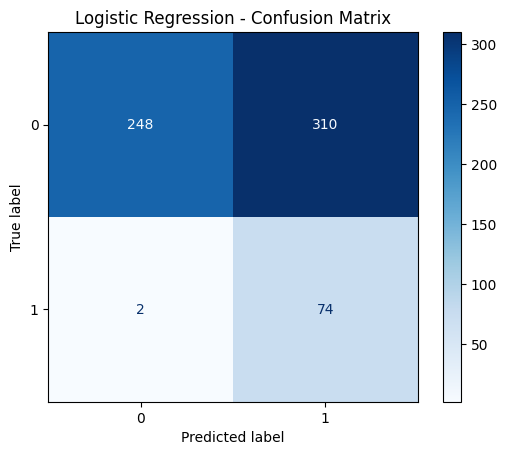


🔹 Training Random Forest...
ROC-AUC: 0.7592
F1-Score: 0.3027
              precision    recall  f1-score   support

         0.0       0.91      0.85      0.88       558
         1.0       0.26      0.37      0.30        76

    accuracy                           0.80       634
   macro avg       0.58      0.61      0.59       634
weighted avg       0.83      0.80      0.81       634



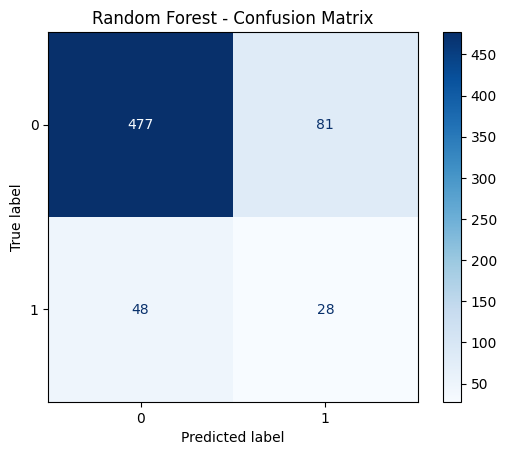


🔹 Training KNN...
ROC-AUC: 0.7480
F1-Score: 0.3857
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.83       558
         1.0       0.26      0.71      0.39        76

    accuracy                           0.73       634
   macro avg       0.61      0.72      0.61       634
weighted avg       0.87      0.73      0.77       634



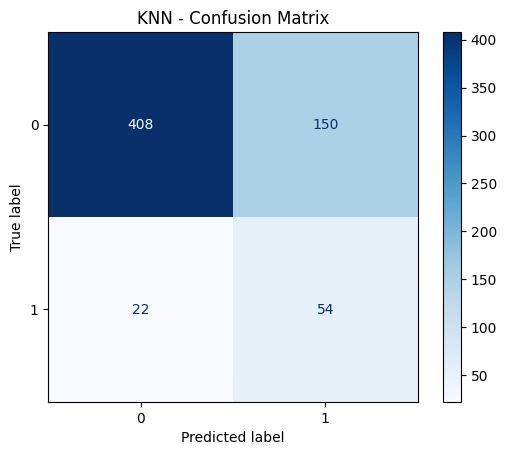


🔹 Training Naive Bayes...
ROC-AUC: 0.7694
F1-Score: 0.3455
              precision    recall  f1-score   support

         0.0       0.95      0.65      0.77       558
         1.0       0.22      0.75      0.35        76

    accuracy                           0.66       634
   macro avg       0.59      0.70      0.56       634
weighted avg       0.86      0.66      0.72       634



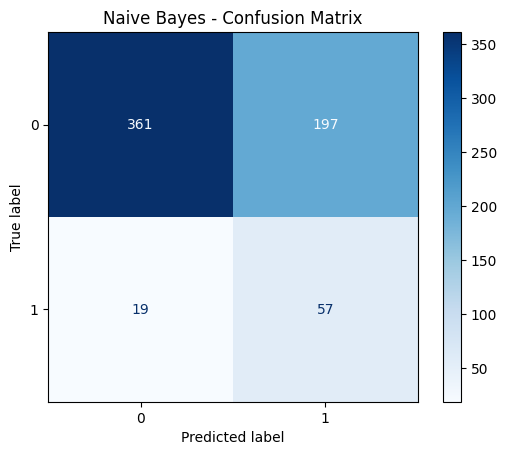


🔹 Training SVM...
ROC-AUC: 0.7819
F1-Score: 0.3774
              precision    recall  f1-score   support

         0.0       0.96      0.67      0.79       558
         1.0       0.25      0.79      0.38        76

    accuracy                           0.69       634
   macro avg       0.60      0.73      0.58       634
weighted avg       0.87      0.69      0.74       634



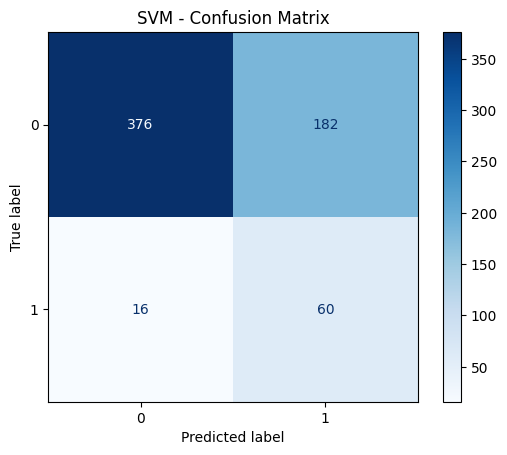


🔹 Training XGBoost...


c:\REPOS\thesis_diabetes\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:54:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC: 0.7588
F1-Score: 0.2993
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91       558
         1.0       0.31      0.29      0.30        76

    accuracy                           0.84       634
   macro avg       0.61      0.60      0.60       634
weighted avg       0.83      0.84      0.84       634



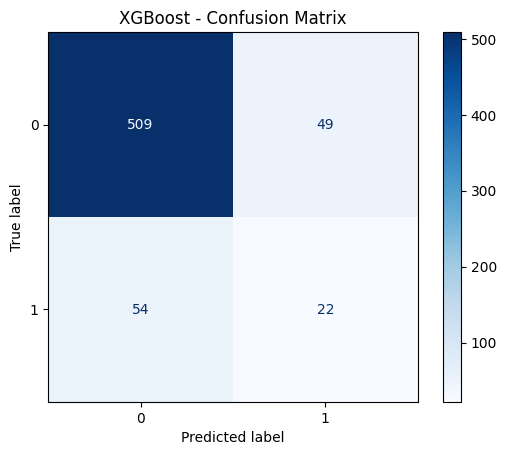

🏆 Best: Logistic Regression with AUC: 0.7840


In [44]:
# 1. Run the function
results = train_and_evaluate_model_SMOTE(models, X_train, y_train, X_test, y_test) 

# 2. Find the best model name based on ROC-AUC
best_model_name = max(results.keys(), key=lambda x: results[x]['roc_auc'])

# 3. Extract the actual model and the score safely
best_model_pipeline = results[best_model_name]['model']
best_score = results[best_model_name]['roc_auc']

print(f"🏆 Best: {best_model_name} with AUC: {best_score:.4f}")

In [46]:

numeric_features = X.columns.tolist()
over = SMOTE()
under = RandomUnderSampler()

preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), numeric_features)],
    remainder='passthrough'  # keep any non-numeric features if present
)

preprocessor_SMOTE = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)
print(numeric_features)

['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm', 'Systolic_BP', 'Diastolic_BP']


In [54]:
best_pipe = ImbPipeline([
    ('preprocess', preprocessor_SMOTE),
    ('over', over),
    ('under', under),
    ('model', LogisticRegression(max_iter=1000,
                                                random_state=42,
                                                penalty='l2',
                                                C=0.1,
                                                class_weight='balanced'
    ))
])

best_pipe.fit(X_train, y_train)
import joblib

# 1. Save (Dump) the model to a file
joblib.dump(best_pipe, 'clinical_nogc.pkl')

['clinical_nogc.pkl']

In [53]:
new_patient = pd.DataFrame([{
    'Age': 21,                # Increased age (T2D risk increases with age)
    'Gender': 1,
    'Height_cm': 168,
    'Weight_kg': 98,        # BMI approx 30 (Obese category)
    'Waist_cm': 98,       # Realistic "at-risk" waist circumference (>40 inches)
    'Hip_cm': 96,
    'Systolic_BP': 135,       # Higher hypertension (common comorbidity)
    'Diastolic_BP': 98,             # Lowered HDL (common in diabetic dyslipidemia)
}])

prob = best_pipe.predict_proba(new_patient)[0]
print(f"Predicted Probability of No Diabetes: {prob[0]*100:.2f}%")
print(f"Predicted Probability of Diabetes: {prob[1]*100:.2f}%")


Predicted Probability of No Diabetes: 79.94%
Predicted Probability of Diabetes: 20.06%


Loading training data...
Training model
------------------------------
HOSPITAL DATA RESULTS
Total Patients: 163
Correct: 148 (90.80%)
Wrong: 15 (9.20%)
------------------------------


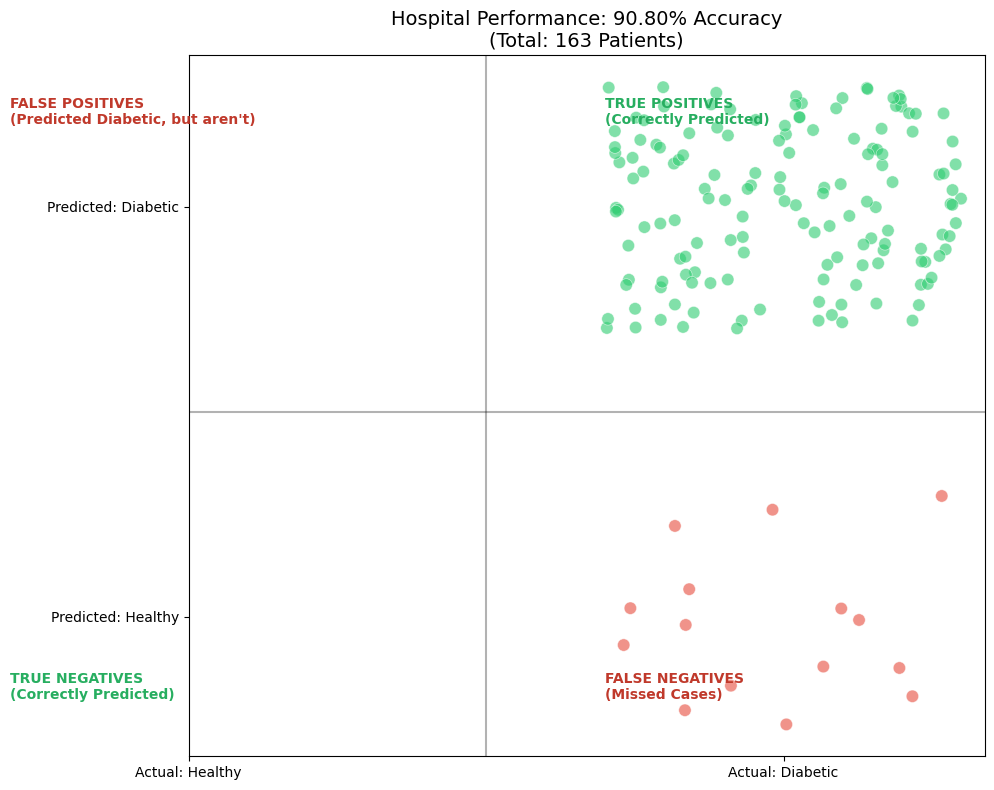

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression

# ==========================================
# 1. LOAD & PREPARE TRAINING DATA
# ==========================================
print("Loading training data...")
train_df = pd.read_csv('merged_data.csv')
train_df['Age_HbA1c'] = train_df['Age'] * train_df['HbA1c']

# Define features used in training
#numeric_features = ['HbA1c']
numeric_features = ['Age', 'Gender', 'Weight_kg', 'Systolic_BP', 'Diastolic_BP', 
                    'HbA1c', 'FBS', 'Cholesterol_Total', 'HDL', 'Age_HbA1c']

# Map target (NHANES: 1=Diabetic, 2=Non-Diabetic -> 1=Positive, 0=Negative)
train_df['Diabetes_Status'] = train_df['Diabetes_Status'].map({1: 1, 2: 0})
train_df = train_df.dropna(subset=['Diabetes_Status'])

X = train_df[numeric_features]
y = train_df['Diabetes_Status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')), 
            ('scaler', StandardScaler())
        ]), numeric_features)
    ]
)

best_pipe = ImbPipeline([
    ('preprocess', preprocessor),
    ('over', SMOTE(random_state=42, sampling_strategy=0.6)),
    ('under', RandomUnderSampler(random_state=42)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=42,
        penalty='l2',
        C=0.1,
        class_weight={0:1, 1: 3}
    ))
])


print("Training model")
best_pipe.fit(X_train, y_train)

ccmc = pd.read_excel('ccmc_dataset/COMPILED_DATASET.xlsx')


ccmc = ccmc.dropna(subset=['HbA1c'])

chol_conversion = 38.67
# Assuming 'scaler' is the object you used on NHANES training data
# 1. Convert units first
ccmc.loc[ccmc['Cholesterol_Total'] < 25, 'Cholesterol_Total'] = ccmc['Cholesterol_Total'] * chol_conversion
ccmc.loc[ccmc['HDL'] < 15, 'HDL'] = ccmc['HDL'] * 38.67
ccmc.loc[ccmc['FBS'] < 20, 'FBS'] = ccmc['FBS'] * 18.01

# Clip extreme outliers to reasonable clinical ranges
ccmc['Age'] = ccmc['Age'].clip(0, 100)
ccmc['Systolic_BP'] = ccmc['Systolic_BP'].clip(40, 250)
ccmc['Diastolic_BP'] = ccmc['Diastolic_BP'].clip(30, 150)

if ccmc['Gender'].dtype == 'object':
    ccmc['Gender'] = ccmc['Gender'].astype(str).str.upper().str.strip()
    ccmc['Gender'] = ccmc['Gender'].map({'M': 1, 'MALE': 1, 'F': 2, 'FEMALE': 2})


for col in numeric_features:
    if col in ccmc.columns and col != 'Gender':
        ccmc[col] = pd.to_numeric(ccmc[col].astype(str).str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
ccmc['Age_HbA1c'] = ccmc['Age'] * ccmc['HbA1c']

ccmc['y_true'] = ccmc['Diabetes_Status'].fillna(0).astype(int)



X_hospital = ccmc[numeric_features]

ccmc['y_pred'] = best_pipe.predict(X_hospital)
ccmc['risk_score'] = best_pipe.predict_proba(X_hospital)[:, 1]


total = len(ccmc)
correct = (ccmc['y_pred'] == ccmc['y_true']).sum()
wrong = total - correct
accuracy = (correct / total) * 100

print("-" * 30)
print(f"HOSPITAL DATA RESULTS")
print(f"Total Patients: {total}")
print(f"Correct: {correct} ({accuracy:.2f}%)")
print(f"Wrong: {wrong} ({100 - accuracy:.2f}%)")
print("-" * 30)


plt.figure(figsize=(10, 8))

xjitter = ccmc['y_true'] + np.random.uniform(-0.3, 0.3, size=len(ccmc))
yjitter = ccmc['y_pred'] + np.random.uniform(-0.3, 0.3, size=len(ccmc))


colors = ['#2ecc71' if row['y_pred'] == row['y_true'] else '#e74c3c' for _, row in ccmc.iterrows()]

plt.scatter(xjitter, yjitter, c=colors, s=80, alpha=0.6, edgecolors='white', linewidth=0.5)


plt.axhline(y=0.5, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.5, color='black', linestyle='-', alpha=0.3)


plt.text(-0.3, 1.2, "FALSE POSITIVES\n(Predicted Diabetic, but aren't)", color='#c0392b', fontweight='bold')
plt.text(0.7, 1.2, "TRUE POSITIVES\n(Correctly Predicted)", color='#27ae60', fontweight='bold')
plt.text(-0.3, -0.2, "TRUE NEGATIVES\n(Correctly Predicted)", color='#27ae60', fontweight='bold')
plt.text(0.7, -0.2, "FALSE NEGATIVES\n(Missed Cases)", color='#c0392b', fontweight='bold')

plt.xticks([0, 1], ["Actual: Healthy", "Actual: Diabetic"])
plt.yticks([0, 1], ["Predicted: Healthy", "Predicted: Diabetic"])
plt.title(f"Hospital Performance: {accuracy:.2f}% Accuracy\n(Total: {total} Patients)", fontsize=14)
plt.grid(False)
 
plt.tight_layout()
plt.show()